In [1]:
import os
import random
import time
import numpy as np
from ase.io import read
from quests.descriptor import get_descriptors
from quests.entropy import delta_entropy, approx_delta_entropy
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [36]:
# get a subset of mptrj
random.seed(88)

def random_sample_from_directory(directory, sample_size):
    files = sorted(os.listdir(directory))  # Get all files
    files = [f for f in files if os.path.isfile(os.path.join(directory, f))]  # Filter only files
    sample = random.sample(files, min(sample_size, len(files)))  # Pick random sample
    return sample

# Example usage
data_dir = "/data/shared/MPTrj/original"
sample_size = 500  # Change to the desired number of files

random_files = random_sample_from_directory(data_dir, sample_size)
print(len(random_files))
print(random_files[0])

500
mp-556927.extxyz


In [ ]:
every_10th = random_files[::10]
structures_1 = []
for filename in every_10th:
    if filename.endswith(".extxyz"):
        filepath = os.path.join(data_dir, filename)
        atoms = read(filepath)  # Load all frames in case of trajectory files
        structures_1.extend(atoms)  # Add structures to list

Atoms(symbols='Rb2Fe2F8', pbc=True, cell=[5.457084, 5.457084, 6.581524], calculator=SinglePointCalculator(...))


In [33]:
# write every 10th filename in random_files into a txt file since i don't want to simulate 500 per model
with open("mptrj_subset_50_ids.txt", "w") as f:
    for i, filename in enumerate(random_files):
        if i % 10 == 0:
            f.write(f"{data_dir}/{filename}\n")

In [20]:
# save the subset to a file
structures_1 = []
for filename in random_files:
    if filename.endswith(".extxyz"):
        filepath = os.path.join(data_dir, filename)
        atoms = read(filepath, index=":")  # Load all frames in case of trajectory files
        structures_1.extend(atoms)  # Add structures to list

In [ ]:
# Reload saved structures
structures = read("mptrj_without_subset.extxyz", index=":")  # Use "mptrj_combined.traj" if using traj format
print(f"Loaded {len(structures)} structures from file.")

Loaded 1575077 structures from file.


In [21]:
# dset_x = read("mptrj_combined.extxyz", index=":")
# dset_y = read("mptrj_subset_500.extxyz", index=":")
dset_y = read("/data/shared/MPTrj/original/mp-1245902.extxyz", index=":")

k, cutoff = 32, 5.0

t0 = time.time()
y = get_descriptors(dset_y, k=k, cutoff=cutoff)
t1 = time.time()
print(f"y get descriptors took {t1-t0:.2f} seconds")

t2 = time.time()
x = get_descriptors(structures_1, k=k, cutoff=cutoff)
t3 = time.time()
print(f"x get descriptors took {t3-t2:.2f} seconds")

# computes dH (Y | X)
t4 = time.time()
dH = delta_entropy(y, x, h=0.015)
t5 = time.time()
print(f"dH took {t5-t4:.2f} seconds")

# this didn't even finish in 45+ min

y get descriptors took 0.55 seconds
x get descriptors took 250.13 seconds
dH took 1.25 seconds


In [17]:
# approximate version
# dset_y = read("mptrj_subset_500.extxyz", index=":")
dset_y = read("/data/shared/MPTrj/original/mp-1245902.extxyz", index=":")

k, cutoff = 32, 5.0

t0 = time.time()
y = get_descriptors(dset_y, k=k, cutoff=cutoff)
t1 = time.time()
print(f"y get descriptors took {t1-t0:.2f} seconds")

t2 = time.time()
x = get_descriptors(structures_1, k=k, cutoff=cutoff)
t3 = time.time()
print(f"x get descriptors took {t3-t2:.2f} seconds")

# computes dH (Y | X)
t4 = time.time()
dH = approx_delta_entropy(y, x, h=0.015, n=5, graph_neighbors=10)
t5 = time.time()
print(f"approximate dH took {t5-t4:.2f} seconds")

y get descriptors took 0.40 seconds
x get descriptors took 26.85 seconds
approximate dH took 50.91 seconds


/home/christine/quests/quests/entropy.py:457: RuntimeWarning: divide by zero encountered in log
  return -np.log(p_y)


In [23]:
y.shape

(264, 63)

In [24]:
x.shape

(171170, 63)

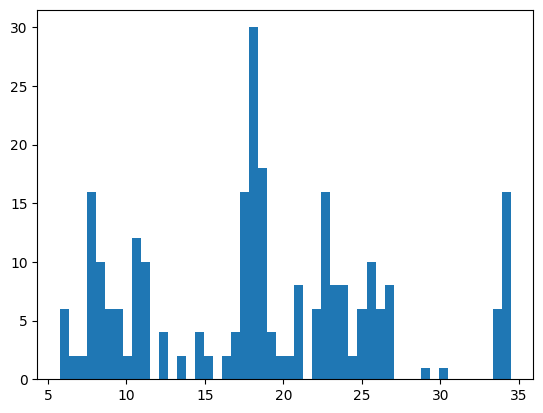

In [ ]:
# make a histogram of the values in dH using pyplot
plt.hist(dH, bins=50)
plt.show()

In [30]:
np.save('y.npy', y)
np.save('x.npy', x)

In [31]:
new_y = np.load('y.npy')
new_x = np.load('x.npy')

In [33]:
new_x.shape

(171170, 63)

In [35]:
print(f"x get descriptors took {(t3-t2) / 60 / 60:.4f} hours")

x get descriptors took 0.0695 hours


In [38]:
dH.shape

(264,)

In [2]:
print("Loading 0th descriptor")
x_desc_0 = np.load("mptrj_without_subset_descriptors_0.npy")

print("Loading 1st descriptor")
x_desc_1 = np.load("mptrj_without_subset_descriptors_1.npy")

print("Loading 2nd descriptor")
x_desc_2 = np.load("mptrj_without_subset_descriptors_2.npy")

print("Loading 3rd descriptor")
x_desc_3 = np.load("mptrj_without_subset_descriptors_3.npy")

print("Loading y descriptor")
y_desc = np.load("mptrj_subset_descriptors.npy")

x_desc = np.vstack((x_desc_0, x_desc_1, x_desc_2, x_desc_3))

Loading 0th descriptor
Loading 1st descriptor
Loading 2nd descriptor
Loading 3rd descriptor
Loading y descriptor


In [8]:
x_desc.shape

(49134625, 63)

In [9]:
y_desc.shape

(161035, 63)

In [ ]:
dH_approx = approx_delta_entropy(y_desc, x_desc, h=0.015, n=5, graph_neighbors=10)
dH_approx.shape

In [2]:
dH = np.load('mptrj_subset_dH.npy')
dH.shape

(161035,)

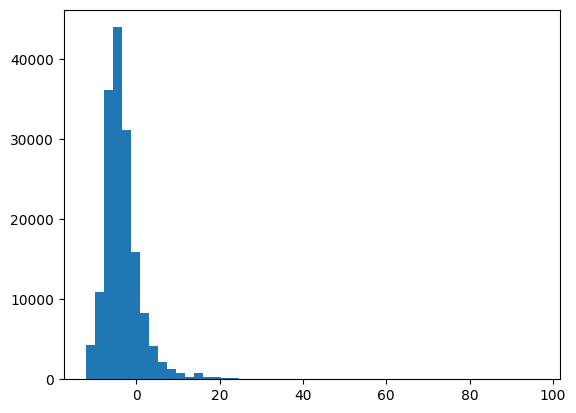

In [ ]:
# histogram of values in dH
dH_finite = dH[np.isfinite(dH)]

plt.hist(dH_finite, bins=50)
plt.show()

In [8]:
dH_finite.shape

(161023,)

## Preparing to analyze results

In [15]:
# seeing which structures correspond to which descriptors
dset_y = read("mptrj/mptrj_subset_500.extxyz", index=":")

k, cutoff = 32, 5.0
result = []

for i, structure in tqdm(enumerate(dset_y)):
    y = get_descriptors([structure], k=k, cutoff=cutoff)
    result.extend([i] * len(y))

len(result)

5318it [02:07, 41.79it/s]


161035

In [19]:
subset_indices = np.array(result)
np.save("mptrj_subset_descriptor_indices.npy", subset_indices)

In [9]:
dset_y = read("/home/christine/quests/mptrj/mptrj_subset_500.extxyz", index=":")
print(len(dset_y)) # not the same length as the descriptors

5318


In [10]:
dset_y

[Atoms(symbols='Rb2Fe2F8', pbc=True, cell=[5.457084, 5.457084, 6.581524], calculator=SinglePointCalculator(...)),
 Atoms(symbols='F8Fe2Rb2', pbc=True, cell=[5.45558483, 5.45558483, 6.57831292], calculator=SinglePointCalculator(...)),
 Atoms(symbols='F8Fe2Rb2', pbc=True, cell=[5.45503236, 5.45503236, 6.57326808], calculator=SinglePointCalculator(...)),
 Atoms(symbols='F8Fe2Rb2', pbc=True, cell=[5.44089922, 5.44089922, 6.54613129], calculator=SinglePointCalculator(...)),
 Atoms(symbols='F8Fe2Rb2', pbc=True, cell=[5.45577911, 5.45577911, 6.56086574], calculator=SinglePointCalculator(...)),
 Atoms(symbols='F8Fe2Rb2', pbc=True, cell=[5.47526808, 5.47526808, 6.55894405], calculator=SinglePointCalculator(...)),
 Atoms(symbols='Rb2Fe2F8', pbc=True, cell=[5.45298542, 5.45298542, 6.54466498], calculator=SinglePointCalculator(...)),
 Atoms(symbols='Rb2Fe2F8', pbc=True, cell=[5.457084, 5.457084, 6.581524], calculator=SinglePointCalculator(...)),
 Atoms(symbols='Ga12O48Sc8Y12', pbc=True, cell=[[-6.

## Analyzing results

In [20]:
dH = np.load('mptrj_subset_dH.npy')
dH[np.isinf(dH)] = 0
dH.shape

(161035,)

In [21]:
subset_indices = np.load("mptrj_subset_descriptor_indices.npy")

In [22]:
# using sum of each structure's descriptors' entropy
# Compute sum per index
sum_entropy_per_index = np.bincount(subset_indices, weights=dH)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(5318,)

In [5]:
# using the max
# Use np.maximum.reduceat to find the max per group
sorted_indices = np.argsort(subset_indices)
sorted_values = dH[sorted_indices]
sorted_indices = subset_indices[sorted_indices]

# Get unique indices and positions where they change
unique_indices, start_idx = np.unique(sorted_indices, return_index=True)
max_values = np.maximum.reduceat(sorted_values, start_idx)

# Create a full array with max values at the correct positions
max_result = np.zeros(5318)
max_result[unique_indices] = max_values

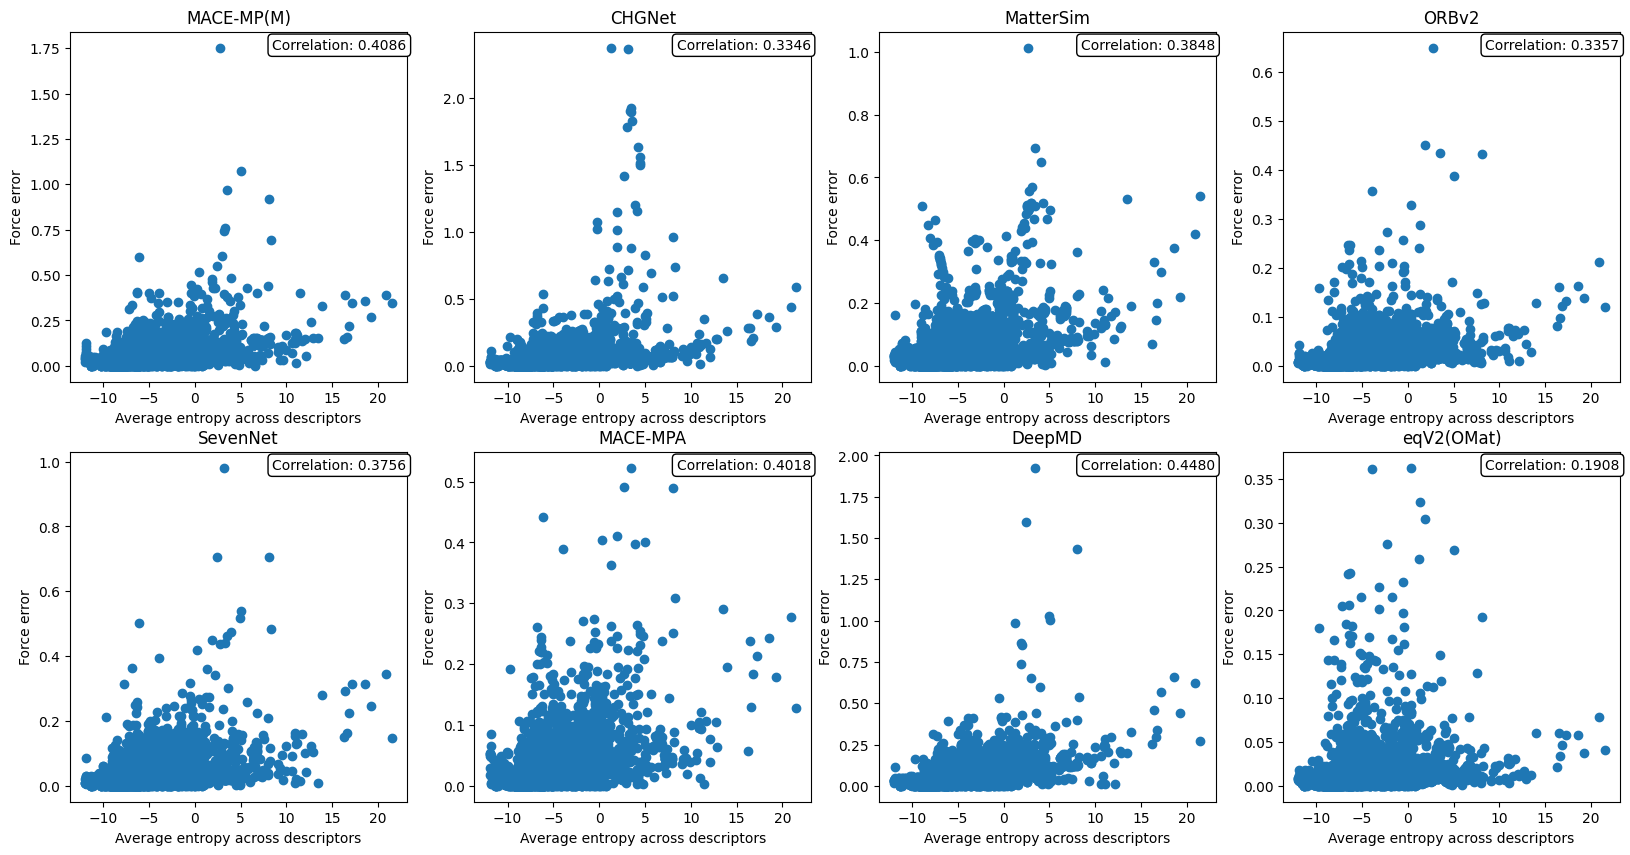

In [23]:
# doing this in one cell for all of the models
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "DeepMD",  "eqV2(OMat)"]
#     # "MACE-MPA", "ORB"
# ]

# create a subplot for each model
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, model_name in enumerate(model_names):
    fname = f'../mlip-arena/{model_name}_force_errors.npy'
    force_errors = np.load(fname)

    # using sum of each structure's descriptors' entropy
    sum_entropy_per_index = np.bincount(subset_indices, weights=dH)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)
    
    # get rid of force error outliers
    mask = force_errors <= 5
    avg_entropies = avg_entropies[mask]
    force_errors = force_errors[mask]

    # produce a scatter plot of avg_values vs. force_errors
    axs.flat[i].scatter(avg_entropies, force_errors)

    # label axes on the subplots
    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Force error")
    axs.flat[i].set_title(f"{model_name}")

    # get the correlation of the scatter plot and label it on the plot
    corr, p_value = pearsonr(avg_entropies, force_errors) # \n p-value: {p_value:.4f}
    axs.flat[i].text(0.6, 0.95, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

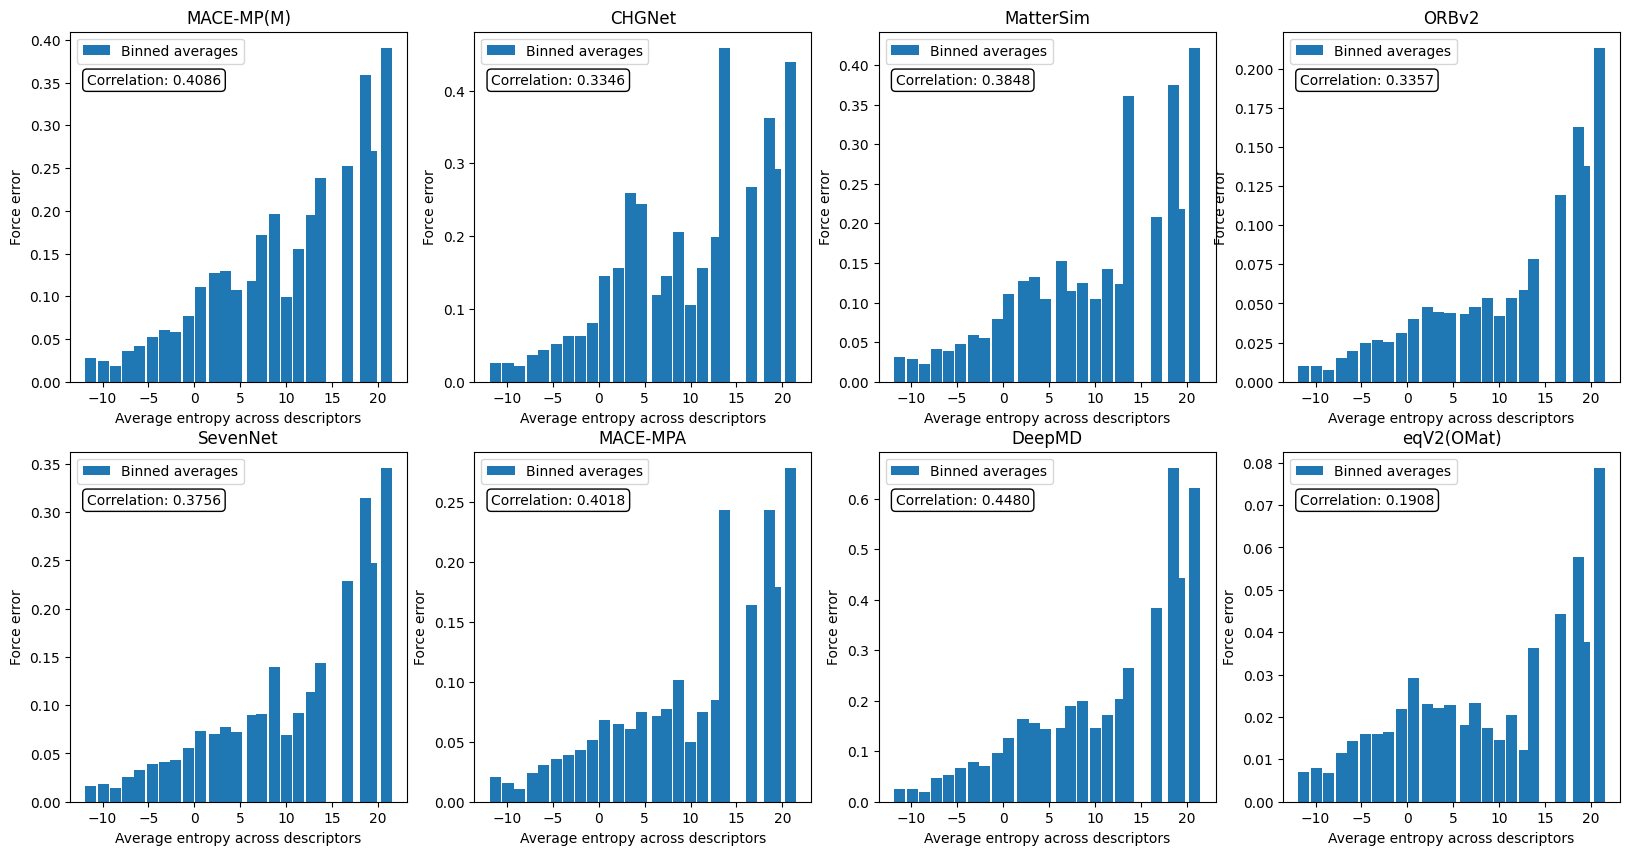

In [26]:
# doing this in one cell for all of the models
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "DeepMD", "eqV2(OMat)"]
#     "eqV2(OMat)", # no permission
#     # "MACE-MPA", "DeepMD", "ORB"
# ]

# Define the number of bins
num_bins = 25

# create a subplot for each model
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, model_name in enumerate(model_names):
    fname = f'../mlip-arena/{model_name}_force_errors.npy'
    force_errors = np.load(fname)

    # using sum of each structure's descriptors' entropy
    sum_entropy_per_index = np.bincount(subset_indices, weights=dH)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)
    
    # get rid of force error outliers
    mask = force_errors <= 5
    avg_entropies = avg_entropies[mask]
    force_errors = force_errors[mask]

    # Compute bin edges
    bin_edges = np.linspace(min(avg_entropies), max(avg_entropies), num_bins + 1)

    # Assign each x-value to a bin
    bin_indices = np.digitize(avg_entropies, bins=bin_edges) - 1  # -1 to make it 0-based

    # Compute the average y-values for each bin
    binned_x = []
    binned_y = []

    for j in range(num_bins):
        mask = bin_indices == j  # Select data points in this bin
        if np.any(mask):  # Avoid empty bins
            binned_x.append(np.mean(avg_entropies[mask]))  # Bin center
            binned_y.append(np.mean(force_errors[mask]))   # Average y-value

    # Plot the binned data
    axs.flat[i].bar(binned_x, binned_y, width=(bin_edges[1] - bin_edges[0]) * 0.9, align='center', label="Binned averages")

    # Label axes and title
    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Force error")
    axs.flat[i].set_title(f"{model_name}")
    axs.flat[i].legend()

    # get the correlation of the scatter plot and label it on the plot
    corr, p_value = pearsonr(avg_entropies, force_errors) # \n p-value: {p_value:.4f}
    axs.flat[i].text(0.05, 0.85, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

## Getting energy conservation from simulations vs entropy

In [2]:
subset_50 = []
with open('../mlip-arena/mptrj_subset_50_ids.txt', 'r') as f:
    for i, line in enumerate(f):
        atoms = read(line.strip())
        subset_50.append(atoms)

len(subset_50)

50

In [3]:
# check that the atoms that you get from just reading the file is the LAST one that you get when you read using index=":"
checks = []
with open('../mlip-arena/mptrj_subset_50_ids.txt', 'r') as f:
    for i, line in enumerate(f):
        atoms = read(line.strip())
        atoms2 = read(line.strip(), index=":")
        checks.append(atoms == atoms2[-1])
print(sum(checks))

50


In [4]:
# from before, copied code
dH = np.load('mptrj_subset_dH.npy')
dH[np.isinf(dH)] = 0
dH.shape

subset_indices = np.load("mptrj_subset_descriptor_indices.npy")

# using sum of each structure's descriptors' entropy
# Compute sum per index
sum_entropy_per_index = np.bincount(subset_indices, weights=dH)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(5318,)

In [5]:
# get the entropy for these structures given that they are the last ones from the other type of reading
dset_y = read("mptrj/mptrj_subset_500.extxyz", index=":")
len(dset_y)

5318

In [6]:
# get a subset of mptrj
random.seed(88)

def random_sample_from_directory(directory, sample_size):
    files = sorted(os.listdir(directory))  # Get all files
    files = [f for f in files if os.path.isfile(os.path.join(directory, f))]  # Filter only files
    sample = random.sample(files, min(sample_size, len(files)))  # Pick random sample
    return sample

# Example usage
data_dir = "/data/shared/MPTrj/original"
sample_size = 500  # Change to the desired number of files

random_files = random_sample_from_directory(data_dir, sample_size)

num_structures_per_file = []
for file in random_files:
    atoms = read(os.path.join(data_dir, file), index=":")
    num_structures_per_file.append(len(atoms))

sum(num_structures_per_file)

5318

In [7]:
# now, extract the items from avg_entropies that correspond to the last structure per file
last_entropies = []
curr_index = 0
for item in num_structures_per_file:
    curr_index += item
    last_entropies.append(avg_entropies[curr_index-1])

print(curr_index)  # should be 5318
len(last_entropies)

5318


500

In [8]:
# we only ran simulations on every 10th of these, and we also excluded structures 4, 9, and 41
sim_entropies = last_entropies[::10]
sim_entropies = np.delete(sim_entropies, [4, 9, 41])
len(sim_entropies)

47

In [28]:
# sim_entropies will be the x-axis for the simulation scatter plots. now we need to get the energy conservation values
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "eqV2(OMat)"]
#     "eqV2(OMat)", "DeepMD", "ORB"

energy_cons = {model_name: [] for model_name in model_names}

for model_name in model_names:
    dir_name = f"../mlip-arena/{model_name}_MPTrj_sims_supercell_1000K"
    for file in sorted(os.listdir(dir_name)):
        traj = read(os.path.join(dir_name, file), index=":")
        # print(len(traj))
        atoms_i = traj[0]
        atoms_f = traj[-1]
        dE = atoms_f.get_total_energy() - atoms_i.get_total_energy()
        energy_cons[model_name].append(dE)

# print the average energy conservation for each model
for model_name in model_names:
    print(f"Average energy conservation for {model_name}: {np.mean(energy_cons[model_name])}")

Average energy conservation for MACE-MP(M): 0.04240042215407444
Average energy conservation for CHGNet: 0.13607068302416883
Average energy conservation for MatterSim: 0.030349755709052833
Average energy conservation for ORBv2: 58.79122831217706
Average energy conservation for SevenNet: 0.024102508448377653
Average energy conservation for MACE-MPA: 0.025932587166430057
Average energy conservation for eqV2(OMat): 8.563859301332842


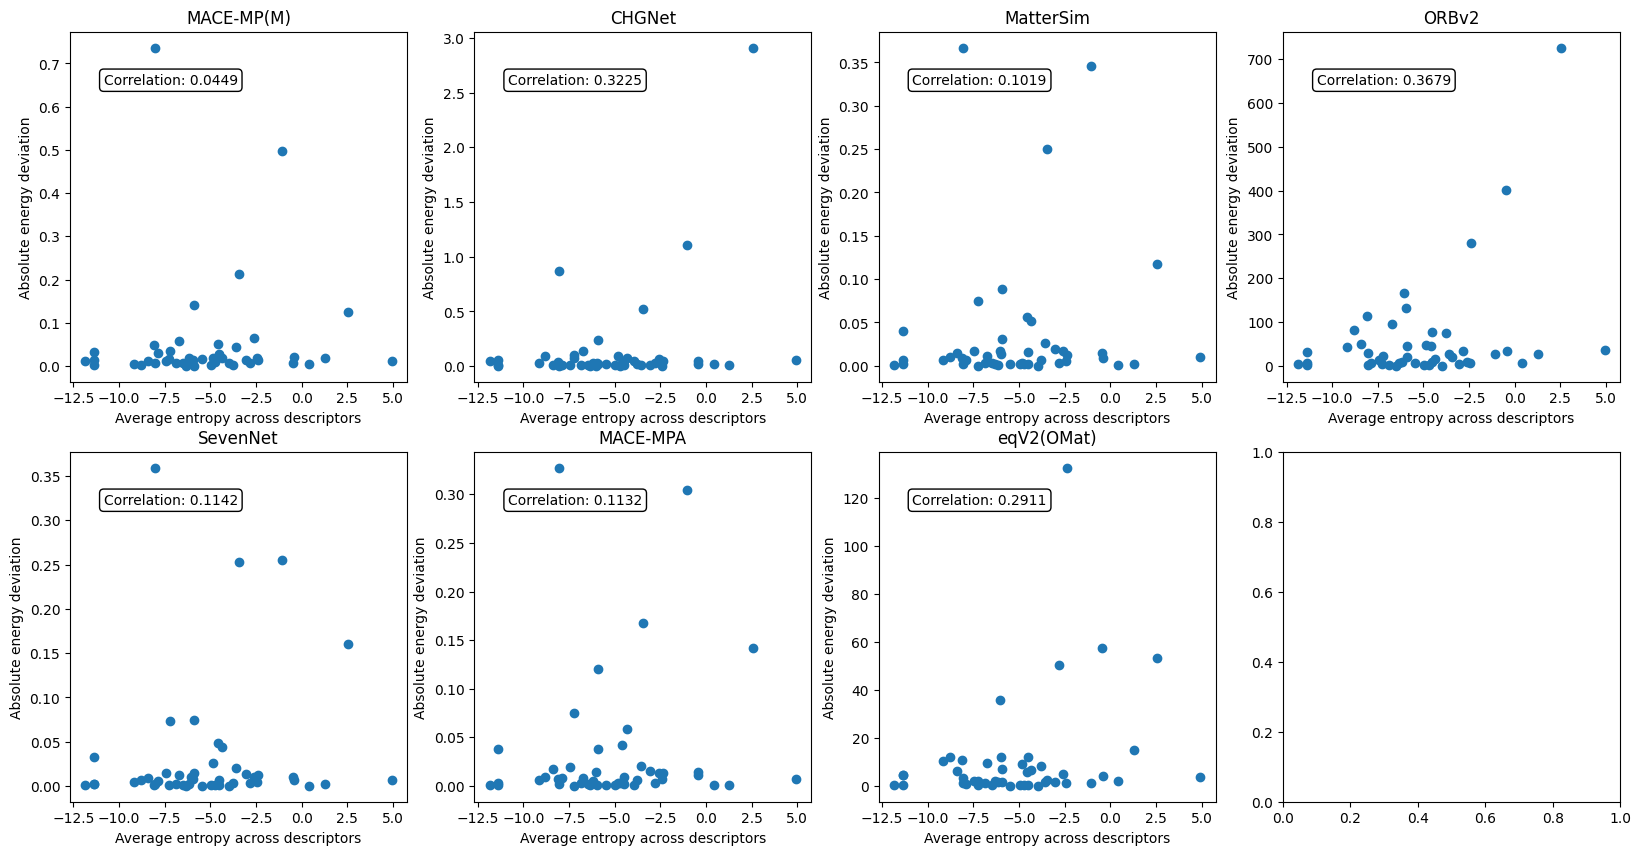

In [37]:
# now we make the scatter plots
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, model_name in enumerate(model_names):
    abs_dev = np.abs(energy_cons[model_name])
    axs.flat[i].scatter(sim_entropies, abs_dev)
    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Absolute energy deviation")
    axs.flat[i].set_title(f"{model_name}")

    corr, p_value = pearsonr(sim_entropies, abs_dev)
    axs.flat[i].text(0.1, 0.85, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

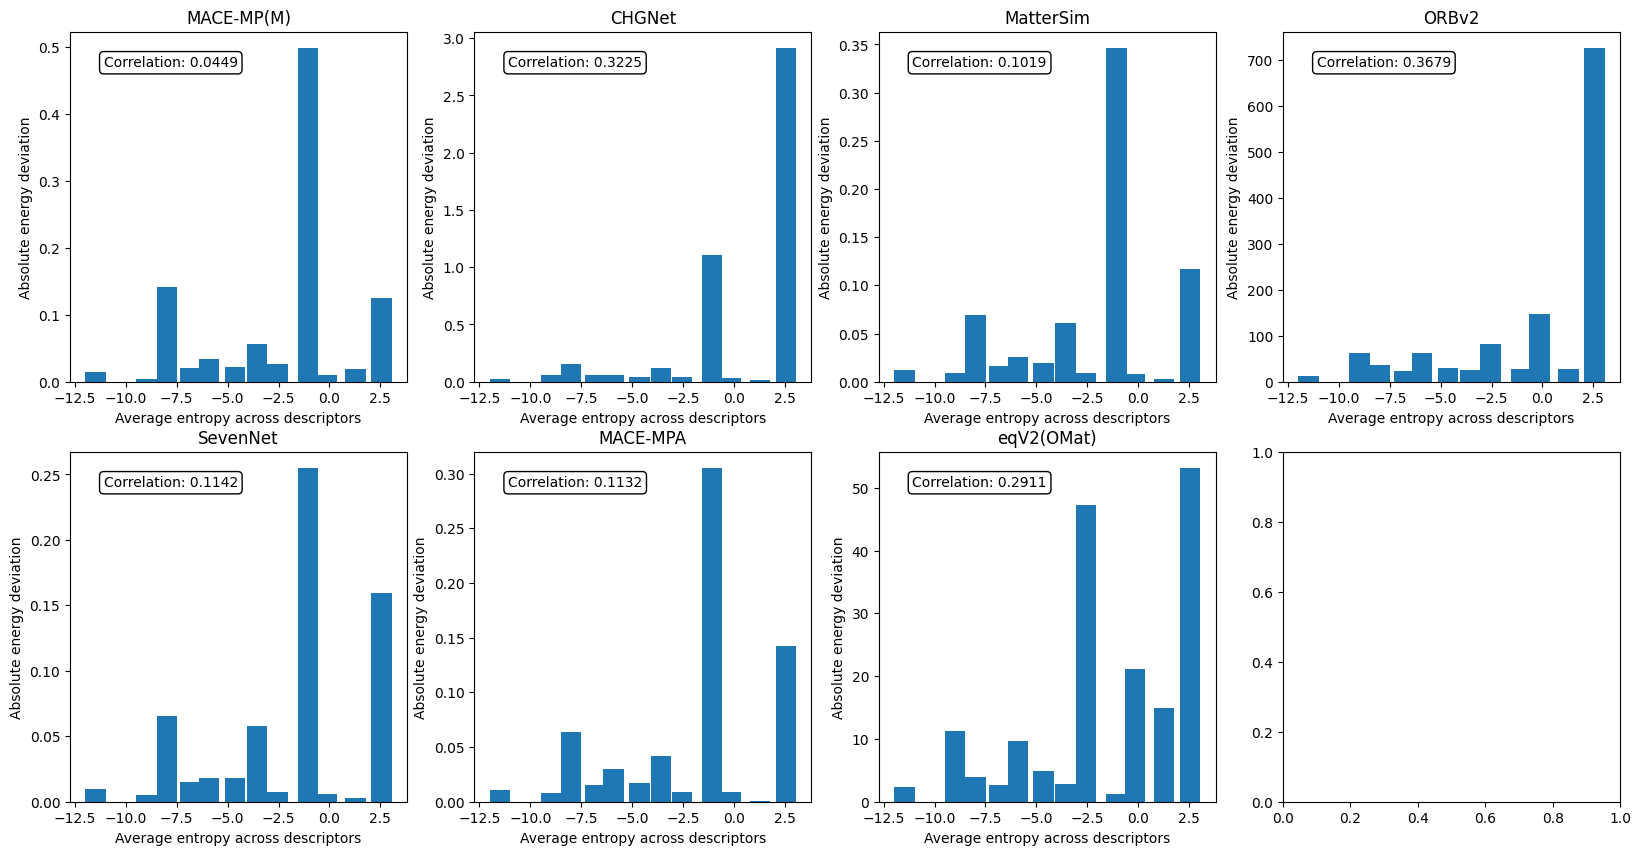

In [46]:
# now we make the binned bar plots
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
num_bins = 15  # or however many bins you want

for i, model_name in enumerate(model_names):
    energy_vals = np.abs(energy_cons[model_name])
    
    # Bin the sim_entropies
    bin_edges = np.linspace(min(sim_entropies), max(sim_entropies), num_bins + 1)
    bin_indices = np.digitize(sim_entropies, bins=bin_edges) - 1  # -1 for 0-based indexing

    binned_x = []
    binned_y = []

    for j in range(num_bins):
        mask = bin_indices == j
        if np.any(mask):
            binned_x.append(np.mean(sim_entropies[mask]))
            binned_y.append(np.mean(energy_vals[mask]))

    axs.flat[i].bar(
        binned_x, binned_y,
        width=(bin_edges[1] - bin_edges[0]) * 0.9,
        align='center',
        label="Binned averages"
    )

    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Absolute energy deviation")
    axs.flat[i].set_title(f"{model_name}")

    # correlation from raw data (not binned)
    corr, p_value = pearsonr(sim_entropies, energy_vals)
    axs.flat[i].text(0.1, 0.9, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))


In [45]:
for model_name in model_names:
    curr_energy_cons = np.array(energy_cons[model_name])
    # print indices for which curr_energy_cons is greater than 5
    num = 100
    indices = np.where(curr_energy_cons > num)[0]
    print(f"Indices for {model_name} where curr_energy_cons > {num}: {indices}")
    
    # # print the corresponding values of sim_entropies
    # print(f"Corresponding values of sim_entropies: {sim_entropies[indices]}")
    # # print the corresponding values of curr_energy_cons
    # print(f"Corresponding values of curr_energy_cons: {curr_energy_cons[indices]}")
    # print()

Indices for MACE-MP(M) where curr_energy_cons > 100: []
Indices for CHGNet where curr_energy_cons > 100: []
Indices for MatterSim where curr_energy_cons > 100: []
Indices for ORBv2 where curr_energy_cons > 100: [ 4 12 14 15 16 33]
Indices for SevenNet where curr_energy_cons > 100: []
Indices for MACE-MPA where curr_energy_cons > 100: []
Indices for eqV2(OMat) where curr_energy_cons > 100: [14]


# SPICE
see sim_analysis.ipynb for getting the spice subset for entropy

In [3]:
dset_y = read('spice/spice_set_10_each.extxyz', index=":")
print(len(dset_y))

70


In [11]:
dset_y[3]

Atoms(symbols='OC2H6OC2H6', pbc=True, cell=[[30.0, 0.0, -1.3113416343912832e-06], [-2.2649369384453166e-06, 30.0, -1.3113416343912832e-06], [0.0, 0.0, 30.0]])

In [5]:
traj = read('../mlip-arena/MACE-OFF(M)_spice_sims_supercell_1000K/54.traj', index=':')
len(traj)

51

## OC20